In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy.stats as stats
import meteostat
import datetime

In [3]:
full_meta_data = pd.read_csv(
    "/Users/michael/Git/Outdoor_microbiome/Local_analysis/Build_expression_matrices_and_metadata/metadata_lookup_tables/Plates_1_to_5_metadata.csv"
)
full_meta_data = full_meta_data.set_index("filename", drop=True)
full_meta_data = full_meta_data.drop_duplicates()
full_meta_data["Experiment Type"] = full_meta_data["timepoint"].str.split("t").str[0]
full_meta_data = full_meta_data.replace("", "Long Term")
full_meta_data = full_meta_data.replace("c1_", "Circadian Experiment 1")
full_meta_data = full_meta_data.replace("c2_", "Circadian Experiment 2")
full_meta_data["Sample Month"] = full_meta_data["date"].str.split("/").str[0]
full_meta_data = full_meta_data.replace(
    {
        "11": "November",
        "12": "December",
        "1": "January",
        "2": "February",
        "3": "March",
        "4": "April",
    }
)
full_meta_data

,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped,Experiment Type,Sample Month
filename,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,334817.0,112554.0,202285.0,22008.0,A,1,2248661.0,1.170940,Long Term,November
A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,776239.0,226718.0,494847.0,49830.0,B,1,5984566.0,0.847878,Long Term,November
A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,427910.0,97848.0,271449.0,28416.0,C,1,2936453.0,0.777471,Long Term,November
A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,177674.0,49095.0,123691.0,13452.0,D,1,1359823.0,0.929141,Long Term,November
A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,309156.0,135512.0,229101.0,26474.0,E,1,2680737.0,1.120708,Long Term,November
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,813353.0,383610.0,550523.0,68933.0,D,12,6510475.0,0.661059,Circadian Experiment 1,February
A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,923444.0,451686.0,560171.0,67290.0,E,12,6178604.0,0.684918,Circadian Experiment 1,February
A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,877561.0,360911.0,638643.0,80102.0,F,12,7035335.0,0.694405,Circadian Experiment 1,February


In [4]:
plate_5_replacements = full_meta_data.loc[full_meta_data["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = full_meta_data.loc[full_meta_data["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = full_meta_data .drop(index=replaced_samples.index)

In [5]:
expression_data = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)

expression_data = expression_data.dropna(how="all", axis=0)
expression_data = expression_data.dropna(how="all", axis=1)


In [22]:
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.0,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.0,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A04,0.000000,3.525287,0.0,0.000000,3.087083,0.0,0.0,32.088437,0.0,9.713347,...,0.000000,40.858815,0.0,2.958454,0.0,0.0,0.804390,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.0,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,0.074367,4.474710,0.0,1.383813,2.059206,0.0,0.0,27.907884,0.0,11.118408,...,3.486989,4.209645,0.0,1.072920,0.0,0.0,0.948096,0.0,0.000000,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.0,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H10,0.000000,0.000000,0.0,0.000000,2.953706,0.0,0.0,36.084398,0.0,0.000000,...,0.000000,4.975538,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.0,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222


In [6]:
full_meta_data = full_meta_data.sort_index()
expression_data = expression_data.sort_index()
full_meta_data

,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped,Experiment Type,Sample Month
filename,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,1,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,285983.0,82176.0,103821.0,14939.0,A,1,1246970.0,0.608101,Long Term,January
A2449446903_n01_LICRNA02_A02,A02,9,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,648887.0,353549.0,398670.0,57289.0,A,2,4985602.0,0.616150,Long Term,January
A2449446903_n01_LICRNA02_A03,A03,17,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,386660.0,158864.0,207527.0,27420.0,A,3,2465662.0,0.492216,Long Term,February
A2449446903_n01_LICRNA02_A04,A04,25,LIC205,plant,t18,2/6/24,8:00,LIC_03,LICRNA_02,306394.0,132266.0,39209.0,46310.0,6783.0,A,4,564891.0,0.542395,Long Term,February
A2449446903_n01_LICRNA02_A05,A05,33,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,170807.0,90929.0,125368.0,19337.0,A,5,1515395.0,0.860130,Long Term,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,64,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,653299.0,438552.0,460177.0,61087.0,H,8,5245242.0,0.486570,Circadian Experiment 1,February
B250508004_n01_LICRNA03_H09,H09,72,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,1225936.0,493699.0,645602.0,93443.0,H,9,7715482.0,0.548020,Circadian Experiment 1,February
B250508004_n01_LICRNA03_H10,H10,80,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,119463.0,39090.0,55347.0,7763.0,H,10,643786.0,0.567106,Circadian Experiment 1,February


In [7]:
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.000000,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.000000,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A04,0.000000,3.525287,0.0,0.000000,3.087083,0.0,0.0,32.088437,0.0,9.713347,...,0.000000,40.858815,0.000000,2.958454,0.0,0.0,0.804390,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.000000,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.000000,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H10,0.000000,0.000000,0.0,0.000000,2.953706,0.0,0.0,36.084398,0.0,0.000000,...,0.000000,4.975538,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.000000,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222
B250508004_n01_LICRNA03_H12,0.000000,3.436049,0.0,2.004263,3.900086,0.0,0.0,28.479105,0.0,1.731854,...,1.828602,5.298163,0.000000,3.657204,0.0,0.0,0.248594,0.0,0.000000,2.553393


In [8]:
full_meta_data[49:100]

,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped,Experiment Type,Sample Month
filename,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_E02,E02,13,LIC173,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,2654140.0,717431.0,333308.0,360223.0,51956.0,E,2,4439426.0,0.597857,Long Term,January
A2449446903_n01_LICRNA02_E03,E03,21,LIC197,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,4101044.0,800490.0,533106.0,490402.0,73676.0,E,3,5634545.0,0.727839,Long Term,February
A2449446903_n01_LICRNA02_E04,E04,29,LIC209,plant,t18,2/6/24,8:00,LIC_03,LICRNA_02,1611086.0,456247.0,246037.0,294043.0,42841.0,E,4,3708986.0,0.434374,Long Term,February
A2449446903_n01_LICRNA02_E05,E05,37,LIC221,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,8275641.0,1217554.0,775014.0,732400.0,117701.0,E,5,8794144.0,0.941040,Long Term,February
A2449446903_n01_LICRNA02_E06,E06,45,LIC233,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1492358.0,421149.0,237035.0,201238.0,32927.0,E,6,2434757.0,0.612939,Long Term,February
A2449446903_n01_LICRNA02_E07,E07,53,LIC245,plant,t21,2/20/24,8:00,LIC_03,LICRNA_02,11738506.0,1479828.0,843365.0,683876.0,105567.0,E,7,8147084.0,1.440823,Long Term,February
A2449446903_n01_LICRNA02_E08,E08,61,LIC257,plant,t22,2/23/24,8:00,LIC_03,LICRNA_02,2844142.0,456709.0,402075.0,250157.0,45821.0,E,8,3084479.0,0.922082,Long Term,February
A2449446903_n01_LICRNA02_E09,E09,69,LIC269,plant,t23,2/26/24,8:00,LIC_03,LICRNA_02,4594369.0,796450.0,553514.0,425070.0,67262.0,E,9,5413707.0,0.848655,Long Term,February
A2449446903_n01_LICRNA02_E10,E10,77,LIC293,plant,t25,3/5/24,8:00,LIC_04,LICRNA_02,1423169.0,378134.0,189051.0,172109.0,29084.0,E,10,2261500.0,0.629303,Long Term,March


In [20]:
expression_data = expression_data.loc[expression_data.index.isin(full_meta_data.index)]

In [23]:
full_meta_data = full_meta_data.loc[full_meta_data.index.isin(expression_data.index)]

In [24]:
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.0,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.0,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A04,0.000000,3.525287,0.0,0.000000,3.087083,0.0,0.0,32.088437,0.0,9.713347,...,0.000000,40.858815,0.0,2.958454,0.0,0.0,0.804390,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.0,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,0.074367,4.474710,0.0,1.383813,2.059206,0.0,0.0,27.907884,0.0,11.118408,...,3.486989,4.209645,0.0,1.072920,0.0,0.0,0.948096,0.0,0.000000,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.0,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H10,0.000000,0.000000,0.0,0.000000,2.953706,0.0,0.0,36.084398,0.0,0.000000,...,0.000000,4.975538,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.0,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222


In [25]:
pca = sklearn.decomposition.PCA(n_components=5).fit_transform(expression_data)
pca

array([[-14527.8990074 ,  -2288.99284954,  -1228.87227381,
         -6870.08594153,  -7600.88737926],
       [ 47178.59617875,   2489.44101612,   4291.26810568,
         -5033.59359694,  -1627.3543993 ],
       [ 64498.7157591 ,   4303.85190625,   6054.82020873,
         -6516.3694974 ,  -4152.37316233],
       ...,
       [ 30928.6356326 , -29315.77541623,  -8369.73567639,
         -8025.56832771,   3113.15797252],
       [-58002.86215038,  -6041.13487499,  -7827.77629095,
        -14752.82349408,   6024.36402688],
       [ 14193.38195334,  35268.63114991,  11412.42651438,
         -1285.26936549,   4191.73656699]], shape=(479, 5))

In [26]:
pca_model = sklearn.decomposition.PCA(n_components=5)
pca_model.fit_transform(expression_data)
pca_model.explained_variance_ratio_

array([0.55041651, 0.21610362, 0.12723102, 0.03500171, 0.0253482 ])

In [27]:
full_meta_data.loc[full_meta_data["Experiment Type"] == "Long Term"]

,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped,Experiment Type,Sample Month
filename,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,1,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,285983.0,82176.0,103821.0,14939.0,A,1,1246970.0,0.608101,Long Term,January
A2449446903_n01_LICRNA02_A02,A02,9,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,648887.0,353549.0,398670.0,57289.0,A,2,4985602.0,0.616150,Long Term,January
A2449446903_n01_LICRNA02_A03,A03,17,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,386660.0,158864.0,207527.0,27420.0,A,3,2465662.0,0.492216,Long Term,February
A2449446903_n01_LICRNA02_A04,A04,25,LIC205,plant,t18,2/6/24,8:00,LIC_03,LICRNA_02,306394.0,132266.0,39209.0,46310.0,6783.0,A,4,564891.0,0.542395,Long Term,February
A2449446903_n01_LICRNA02_A05,A05,33,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,170807.0,90929.0,125368.0,19337.0,A,5,1515395.0,0.860130,Long Term,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_G04,G04,31,LIC367,plant,t08,12/5/23,8:00,LIC_04,LICRNA_03,1477644.0,576615.0,189073.0,233308.0,31719.0,G,4,2732871.0,0.540693,Long Term,December
B250508004_n01_LICRNA03_H01,H01,8,LIC332,plant,t28,3/14/24,8:00,LIC_04,LICRNA_03,5963067.0,1282810.0,589822.0,778042.0,109030.0,H,1,9338754.0,0.638529,Long Term,March
B250508004_n01_LICRNA03_H02,H02,16,LIC344,plant,t24,3/1/24,8:00,LIC_04,LICRNA_03,275002.0,168251.0,47458.0,53182.0,8771.0,H,2,717003.0,0.383544,Long Term,March


In [28]:
pca

array([[-14527.8990074 ,  -2288.99284954,  -1228.87227381,
         -6870.08594153,  -7600.88737926],
       [ 47178.59617875,   2489.44101612,   4291.26810568,
         -5033.59359694,  -1627.3543993 ],
       [ 64498.7157591 ,   4303.85190625,   6054.82020873,
         -6516.3694974 ,  -4152.37316233],
       ...,
       [ 30928.6356326 , -29315.77541623,  -8369.73567639,
         -8025.56832771,   3113.15797252],
       [-58002.86215038,  -6041.13487499,  -7827.77629095,
        -14752.82349408,   6024.36402688],
       [ 14193.38195334,  35268.63114991,  11412.42651438,
         -1285.26936549,   4191.73656699]], shape=(479, 5))

(array([-400000., -300000., -200000., -100000.,       0.,  100000.,
         200000.,  300000.,  400000.]),
 [Text(0, -400000.0, '−400000'),
  Text(0, -300000.0, '−300000'),
  Text(0, -200000.0, '−200000'),
  Text(0, -100000.0, '−100000'),
  Text(0, 0.0, '0'),
  Text(0, 100000.0, '100000'),
  Text(0, 200000.0, '200000'),
  Text(0, 300000.0, '300000'),
  Text(0, 400000.0, '400000')])

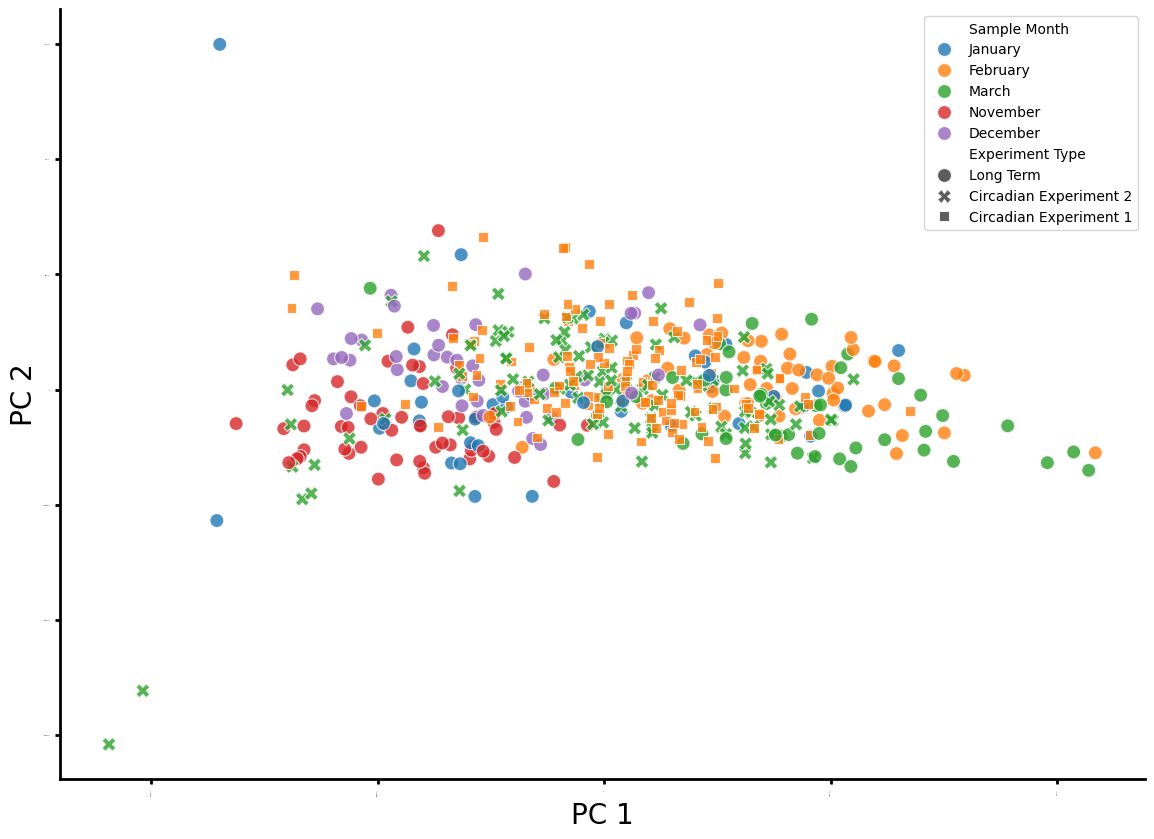

In [44]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    hue=full_meta_data["Sample Month"],
    style=full_meta_data["Experiment Type"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PC 1", fontsize=20)
plt.ylabel("PC 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

array([0.67809966, 0.19184201, 0.05122127, 0.03365849, 0.02070434])

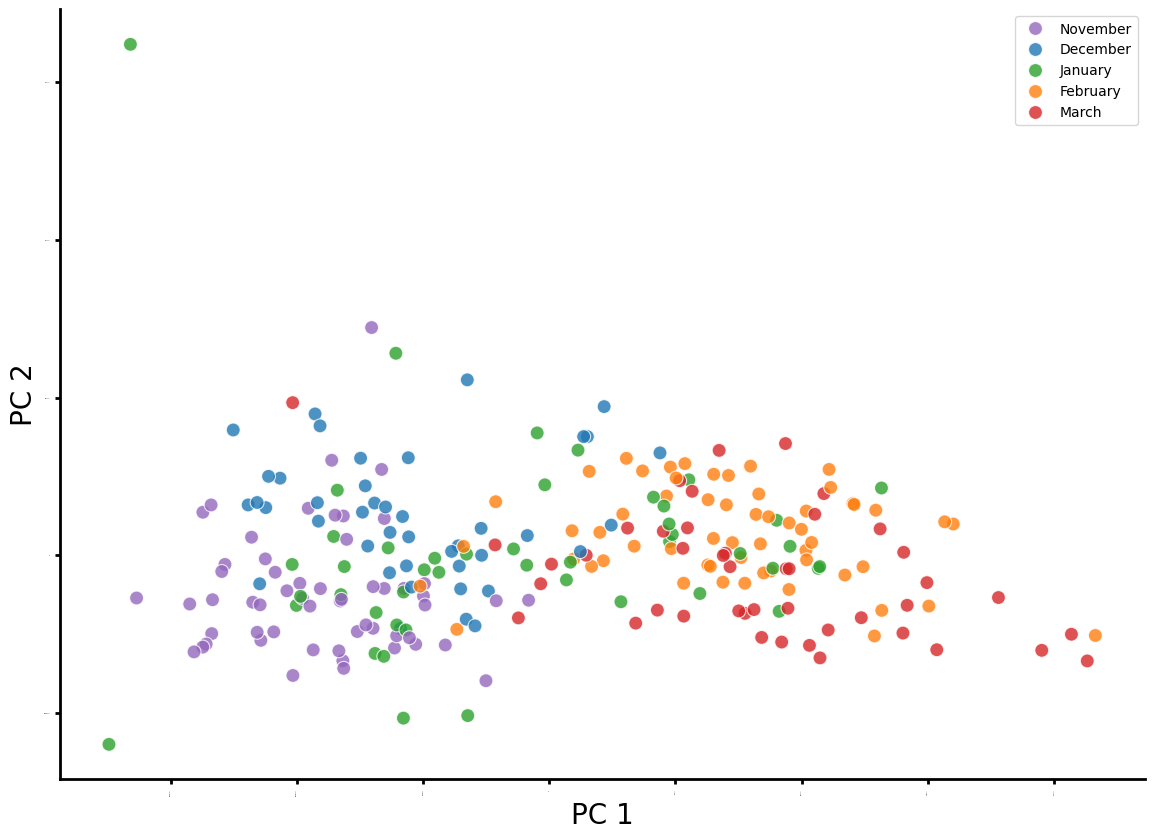

In [45]:
long_term_meta_data = full_meta_data.loc[
    full_meta_data["Experiment Type"] == "Long Term"
].copy()
long_term_expression_data = expression_data.loc[long_term_meta_data.index]

long_term_pca_model = sklearn.decomposition.PCA(n_components=5)
long_term_pca = long_term_pca_model.fit_transform(long_term_expression_data)

month_order = ["November", "December", "January", "February", "March"]
month_palette = {
    "November": "tab:purple",
    "December": "tab:blue",
    "January": "tab:green",
    "February": "tab:orange",
    "March": "tab:red",
}

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=long_term_pca[:, 0],
    y=long_term_pca[:, 1],
    hue=long_term_meta_data["Sample Month"],
    hue_order=month_order,
    palette=month_palette,
    s=100,
    alpha=0.8,
)
plt.xlabel("PC 1", fontsize=20)
plt.ylabel("PC 2", fontsize=20)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.legend(loc="upper right")
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)

long_term_pca_model.explained_variance_ratio_

array([0.46168965, 0.30769607, 0.17096109, 0.01824236, 0.01402116])

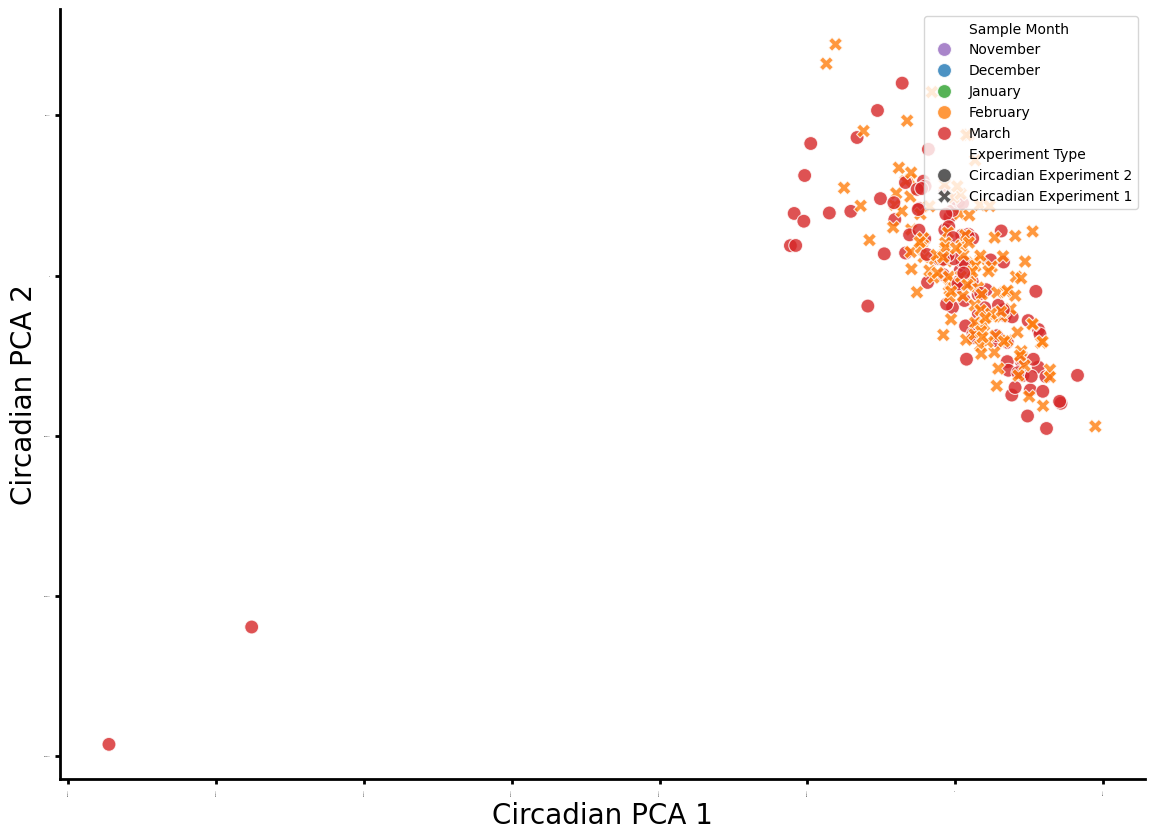

In [39]:
circadian_meta_data = full_meta_data.loc[
    full_meta_data["Experiment Type"].isin(["Circadian Experiment 1", "Circadian Experiment 2"])
].copy()
circadian_expression_data = expression_data.loc[circadian_meta_data.index]

circadian_pca_model = sklearn.decomposition.PCA(n_components=5)
circadian_pca = circadian_pca_model.fit_transform(circadian_expression_data)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=circadian_pca[:, 0],
    y=circadian_pca[:, 1],
    hue=circadian_meta_data["Sample Month"],
    hue_order=month_order,
    palette=month_palette,
    style=circadian_meta_data["Experiment Type"],
    s=100,
    alpha=0.8,
)
plt.xlabel("Circadian PCA 1", fontsize=20)
plt.ylabel("Circadian PCA 2", fontsize=20)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.legend(loc="upper right")
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)

circadian_pca_model.explained_variance_ratio_

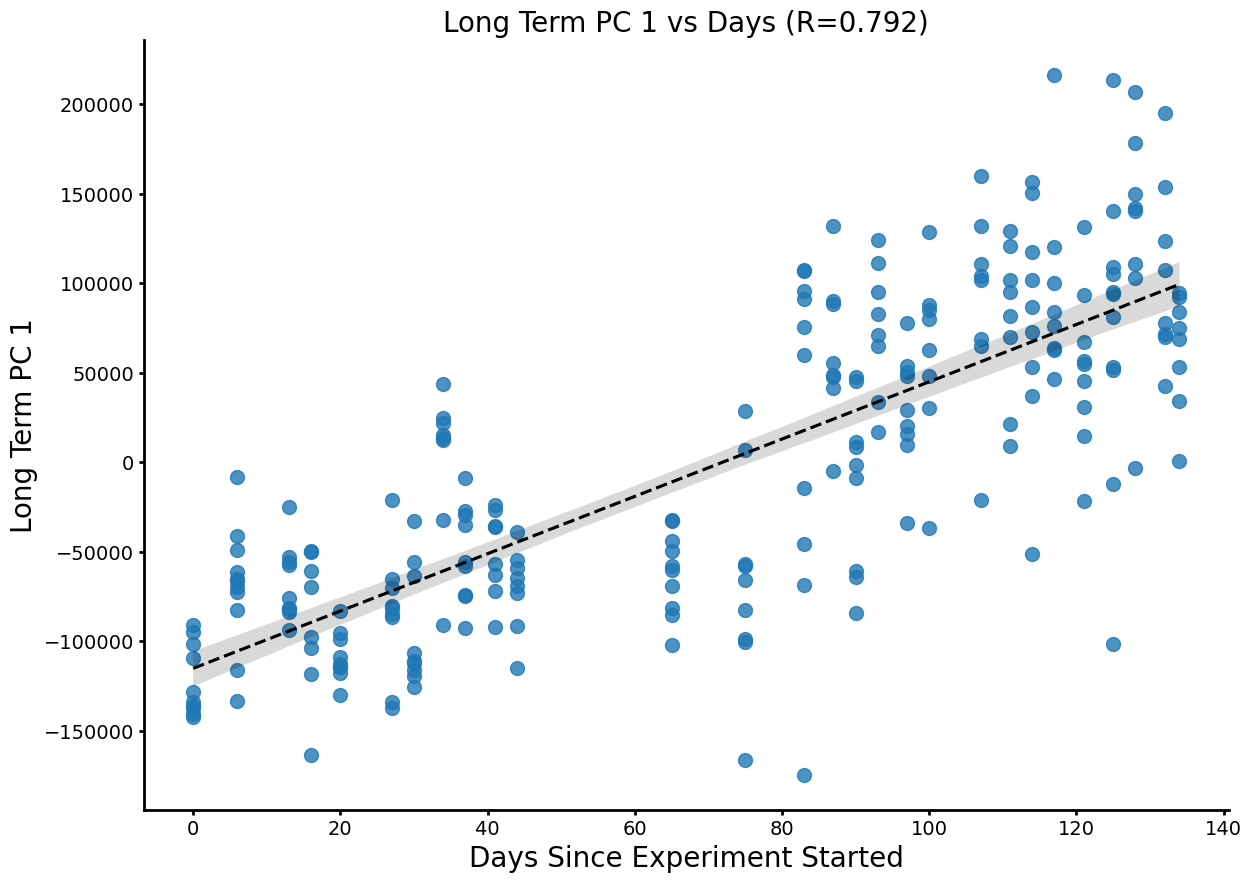

In [50]:
long_term_dates = pd.to_datetime(long_term_meta_data["date"])
days_since_start = (long_term_dates - long_term_dates.min()).dt.days

slope, intercept, r_value, p_value, std_err = stats.linregress(days_since_start, long_term_pca[:, 0])

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
r, _ = stats.pearsonr(days_since_start, long_term_pca[:, 0])
sns.regplot(
    x=days_since_start,
    y=long_term_pca[:, 0],
    scatter_kws={"s": 100, "alpha": 0.8},
    line_kws={"color": "k", "linestyle": "--"},
    ax=ax
)

plt.xlabel("Days Since Experiment Started", fontsize=20)
plt.ylabel("Long Term PC 1", fontsize=20)
plt.title(f"Long Term PC 1 vs Days (R={r:.3f})", fontsize=20)

sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=14)

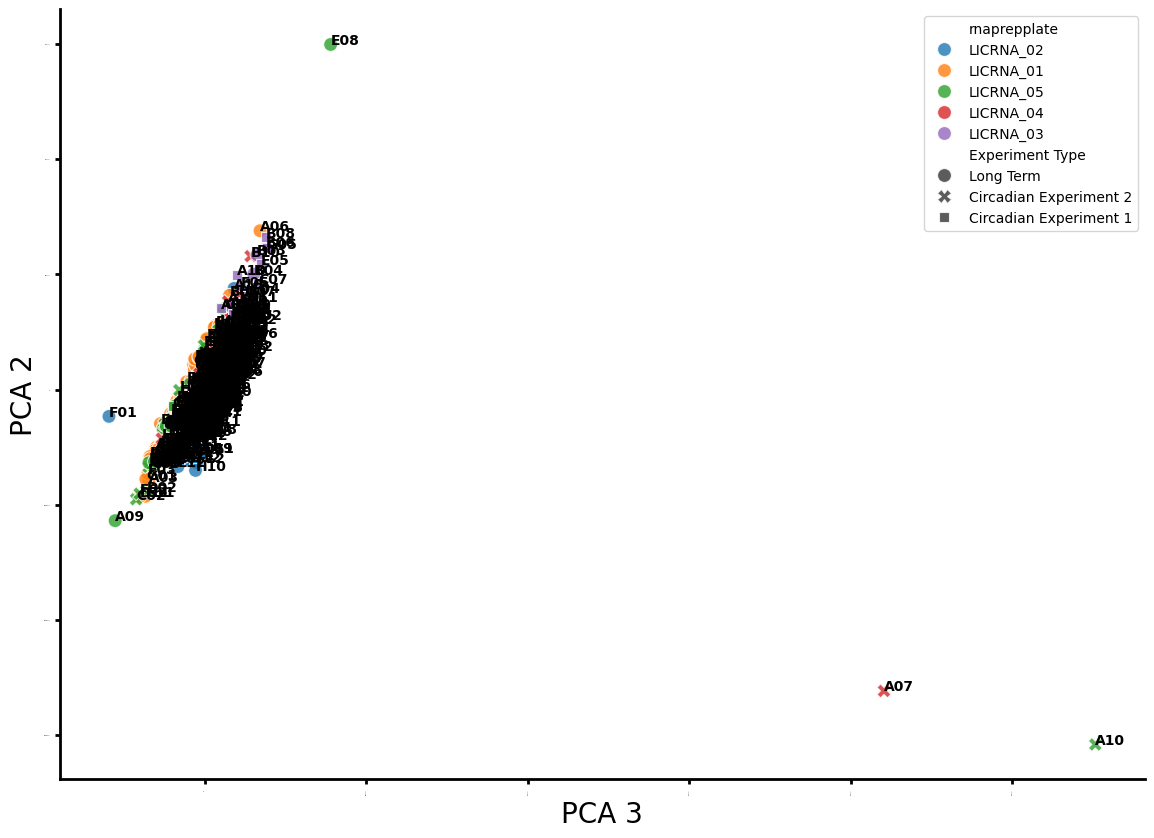

In [37]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 2],
    y=pca[:, 1],
    hue=full_meta_data["rnaprepplate"],
    style=full_meta_data["Experiment Type"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 3", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
for line in range(0, full_meta_data.shape[0]):
    ax.text(
        pca[:, 2][line] + 0.01,
        pca[:, 1][line],
        full_meta_data["plate.pos"][line],
        horizontalalignment="left",
        size="medium",
        color="black",
        weight="semibold",
    )

# plt.ylim(0,10)

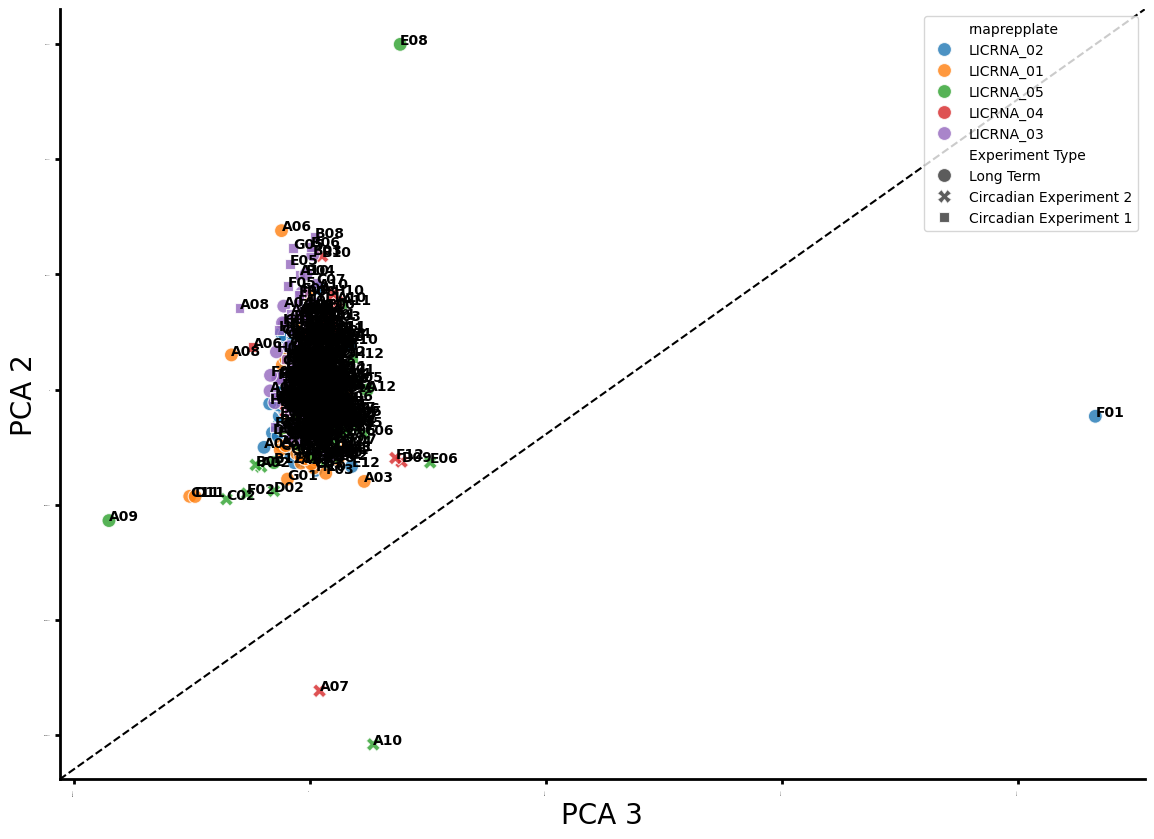

In [33]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 3],
    y=pca[:, 1],
    hue=full_meta_data["rnaprepplate"],
    style=full_meta_data["Experiment Type"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 3", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
ax.plot(
    [0, 1], [0, 1], transform=ax.transAxes, linestyle="dashed", color="k", linewidth=1.5
)
for line in range(0, full_meta_data.shape[0]):
    ax.text(
        pca[:, 3][line] + 0.01,
        pca[:, 1][line],
        full_meta_data["plate.pos"][line],
        horizontalalignment="left",
        size="medium",
        color="black",
        weight="semibold",
    )

# plt.ylim(0,10)

In [34]:
## Things to check - days from germination, time of sampling, weather data impact (temp, humidity, time since last rain, ) correlation of Luke data with weather data
## Worries -correlation of weather and time from germination, correlation of

In [35]:
stations_nearby_NYU = meteostat.Stations().nearby(40.73005, -73.99450)
stations_nearby_NYU.fetch(5)

,name,country,region,wmo,icao,latitude,longitude,elevation,timezone,hourly_start,hourly_end,daily_start,daily_end,monthly_start,monthly_end,distance
id,,,,,,,,,,,,,,,,
KJRB0,New York / Wall Street,US,NY,<NA>,KJRB,40.7012,-74.0090,2.0,America/New_York,2016-07-20,2026-03-10,2016-07-21,2022-04-24,2019-01-01,2021-01-01,3432.864371
KNYC0,New York City / Yorkville,US,NY,<NA>,KNYC,40.7789,-73.9692,3.0,America/New_York,1943-12-01,2026-03-10,1943-12-02,2022-04-24,1944-01-01,2021-01-01,5834.951677
72503,LaGuardia Airport,US,NY,72503,KLGA,40.7792,-73.8800,7.0,America/New_York,1973-01-01,2026-03-10,1939-10-07,2026-03-25,1939-01-01,2022-01-01,11085.363180
KTEB0,Teterboro,US,NJ,<NA>,KTEB,40.8501,-74.0608,3.0,America/New_York,1973-01-01,2026-03-10,1973-01-01,2022-04-24,2005-01-01,2022-01-01,14468.876601
72502,Newark Airport,US,NJ,72502,KEWR,40.6825,-74.1694,5.0,America/New_York,1973-01-01,2026-03-10,1843-05-01,2026-03-25,1893-01-01,2022-01-01,15662.242449


In [24]:
start_time = datetime.datetime(2023, 11, 1)
end_time = datetime.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()

In [25]:
luke_hourly_data["prcp"].value_counts().head(20)

prcp
0.0    3742
0.2      83
0.3      59
0.4      50
0.1      49
0.5      46
0.7      31
1.0      26
0.6      23
0.9      22
0.8      21
1.2      15
1.1      12
1.5      12
1.3      12
2.0      10
2.5      10
2.3       9
1.8       8
2.7       7
Name: count, dtype: Int64

In [26]:
luke_hourly_data[2400:2450]

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2024-02-09 00:00:00,6.1,-0.6,62.0,0.0,<NA>,153.0,5.4,<NA>,1025.0,<NA>,3.0
2024-02-09 01:00:00,6.1,-0.6,62.0,0.0,<NA>,166.0,7.6,<NA>,1024.7,<NA>,3.0
2024-02-09 02:00:00,6.7,-0.1,62.0,0.0,<NA>,158.0,9.4,<NA>,1024.5,<NA>,3.0
2024-02-09 03:00:00,6.1,0.6,68.0,0.0,<NA>,168.0,5.4,<NA>,1024.6,<NA>,3.0
2024-02-09 04:00:00,6.1,1.6,73.0,0.0,<NA>,240.0,5.4,<NA>,1024.6,<NA>,3.0
2024-02-09 05:00:00,5.6,1.1,73.0,0.0,<NA>,240.0,11.2,<NA>,1024.7,<NA>,3.0
2024-02-09 06:00:00,5.0,0.6,73.0,0.0,<NA>,220.0,5.4,<NA>,1024.0,<NA>,3.0
2024-02-09 07:00:00,5.6,-0.7,64.0,0.2,<NA>,0.0,0.0,<NA>,1022.6,<NA>,19.0
2024-02-09 08:00:00,5.6,-1.1,62.0,0.0,<NA>,0.0,0.0,<NA>,1022.6,<NA>,3.0


In [27]:
luke_hourly_data.tail(50)

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2024-04-27 23:00:00,11.1,-0.1,46.0,0.0,<NA>,200.0,18.4,<NA>,1029.8,<NA>,3.0
2024-04-28 00:00:00,11.1,2.1,54.0,0.0,<NA>,180.0,11.2,<NA>,1029.3,<NA>,3.0
2024-04-28 01:00:00,11.1,4.3,63.0,0.0,<NA>,180.0,13.0,<NA>,1029.1,<NA>,3.0
2024-04-28 02:00:00,10.6,5.6,71.0,0.0,<NA>,190.0,7.6,<NA>,1029.2,<NA>,3.0
2024-04-28 03:00:00,10.6,5.6,71.0,0.0,<NA>,180.0,9.4,<NA>,1028.4,<NA>,3.0
2024-04-28 04:00:00,10.6,4.9,68.0,0.2,<NA>,190.0,9.4,<NA>,1027.8,<NA>,7.0
2024-04-28 05:00:00,10.6,5.6,71.0,0.1,<NA>,200.0,9.4,<NA>,1027.0,<NA>,7.0
2024-04-28 06:00:00,10.0,6.2,77.0,0.0,<NA>,220.0,9.4,<NA>,1026.4,<NA>,3.0
2024-04-28 07:00:00,10.0,7.2,83.0,0.0,<NA>,0.0,0.0,<NA>,1025.6,<NA>,3.0


In [28]:
luke_self_collected_temp = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/lic_temp_540000007D5FFE41_031824.csv",
    skiprows=19,
)
luke_self_collected_temp

,Date/Time,Unit,Value
0,11/13/23 6:28:01 PM,C,26.621
1,11/13/23 8:28:01 PM,C,20.117
2,11/13/23 10:28:01 PM,C,8.085
3,11/14/23 12:28:01 AM,C,7.081
4,11/14/23 2:28:01 AM,C,6.579
...,...,...,...
1507,3/18/24 9:28:01 AM,C,17.613
1508,3/18/24 11:28:01 AM,C,21.119
1509,3/18/24 1:28:01 PM,C,22.620
1510,3/18/24 3:28:01 PM,C,22.620


In [ ]:
luke_time_data_format = "%-m/%-d/%y %-I:%-M:%S %p"
luke_self_collected_temp["Date and Time"] = datetime.datetime.strptime(
    luke_self_collected_temp["Date/Time"][0], luke_time_data_format
)
luke_self_collected_temp

,Date/Time,Unit,Value,Date and Time
0,11/13/23 6:28:01 PM,C,26.621,2023-11-13 18:28:01
1,11/13/23 8:28:01 PM,C,20.117,2023-11-13 18:28:01
2,11/13/23 10:28:01 PM,C,8.085,2023-11-13 18:28:01
3,11/14/23 12:28:01 AM,C,7.081,2023-11-13 18:28:01
4,11/14/23 2:28:01 AM,C,6.579,2023-11-13 18:28:01
...,...,...,...,...
1507,3/18/24 9:28:01 AM,C,17.613,2023-11-13 18:28:01
1508,3/18/24 11:28:01 AM,C,21.119,2023-11-13 18:28:01
1509,3/18/24 1:28:01 PM,C,22.620,2023-11-13 18:28:01
1510,3/18/24 3:28:01 PM,C,22.620,2023-11-13 18:28:01


In [29]:
start_time

datetime.datetime(2023, 11, 1, 0, 0)